In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import warnings
from pandas.errors import SettingWithCopyWarning
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
warnings.filterwarnings("ignore", category=SettingWithCopyWarning)

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/sylviacoder/SmartCare-Healthcare-Insurance-Claim-Fraud-Detection-/refs/heads/main/synthetic_health_claims.csv')

In [7]:
df.head()

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,Rehab/Skilled Nursing,47,Inpatient,3440.06,824.59,0,16,939.08,True,False
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,Deceased,0,Outpatient,3618.40,851.43,0,6,170.40,False,True
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,Deceased,0,Pharmacy,2442.41,616.23,0,2,549.38,True,False
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,Deceased,0,Pharmacy,587.78,459.33,0,2,396.49,False,True
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,Deceased,0,Emergency Room,3047.55,847.40,0,15,865.87,True,False


In [9]:
df.isnull().sum()

Patient_ID                            0
Policy_Number                         0
Claim_ID                              0
Claim_Date                            0
Service_Date                          0
Policy_Expiration_Date                0
Claim_Amount                          0
Patient_Age                           0
Patient_Gender                        0
Patient_City                          0
Patient_State                         0
Hospital_ID                           0
Provider_Type                         0
Provider_Specialty                    0
Provider_City                         0
Provider_State                        0
Diagnosis_Code                        0
Procedure_Code                        0
Number_of_Procedures                  0
Admission_Type                        0
Discharge_Type                        0
Length_of_Stay_Days                   0
Service_Type                          0
Deductible_Amount                     0
CoPay_Amount                          0


In [11]:
df.describe()

,Patient_ID,Claim_ID,Claim_Amount,Patient_Age,Hospital_ID,Procedure_Code,Number_of_Procedures,Length_of_Stay_Days,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles
count,2.010000e+04,20100.000000,2.010000e+04,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000
mean,5.528158e+07,10005.580348,1.245349e+06,45.104925,500.204179,92463.849851,5.510249,4.975821,2508.487758,499.665796,0.000299,10.027910,499.480532
std,2.606038e+07,5774.135663,6.983001e+05,26.300942,288.437500,8151.470654,2.882847,13.239804,1443.579069,288.397727,0.017275,6.622332,289.745360
min,1.000265e+07,1.000000,5.516780e+03,0.000000,1.000000,71045.000000,1.000000,0.000000,0.030000,0.020000,0.000000,0.000000,0.020000
25%,3.266819e+07,5005.750000,6.674103e+05,22.000000,251.000000,93040.000000,3.000000,0.000000,1251.440000,248.800000,0.000000,5.000000,246.380000
50%,5.551009e+07,10008.500000,1.221707e+06,45.000000,500.000000,93571.000000,6.000000,0.000000,2508.875000,499.950000,0.000000,10.000000,498.410000
75%,7.814105e+07,15011.250000,1.835603e+06,68.000000,752.000000,99204.000000,8.000000,0.000000,3755.080000,750.040000,0.000000,15.000000,751.000000
max,9.998440e+07,20000.000000,2.499689e+06,90.000000,1000.000000,99284.000000,10.000000,60.000000,4999.870000,999.880000,1.000000,34.000000,999.980000


In [13]:
df.dtypes

Patient_ID                              int64
Policy_Number                          object
Claim_ID                                int64
Claim_Date                             object
Service_Date                           object
Policy_Expiration_Date                 object
Claim_Amount                          float64
Patient_Age                             int64
Patient_Gender                         object
Patient_City                           object
Patient_State                          object
Hospital_ID                             int64
Provider_Type                          object
Provider_Specialty                     object
Provider_City                          object
Provider_State                         object
Diagnosis_Code                         object
Procedure_Code                          int64
Number_of_Procedures                    int64
Admission_Type                         object
Discharge_Type                         object
Length_of_Stay_Days               

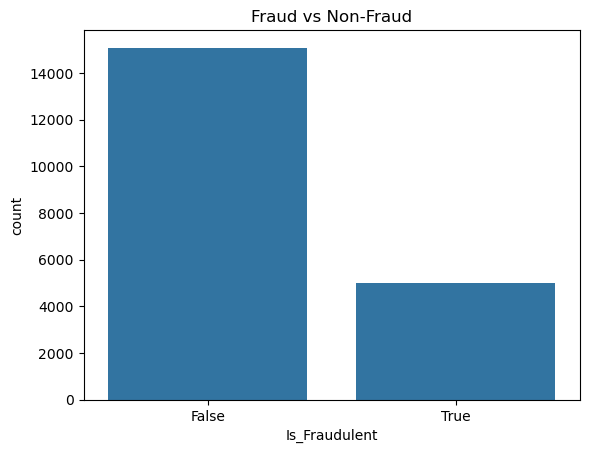

In [15]:
sns.countplot(x=df["Is_Fraudulent"])
plt.title("Fraud vs Non-Fraud")
plt.show()

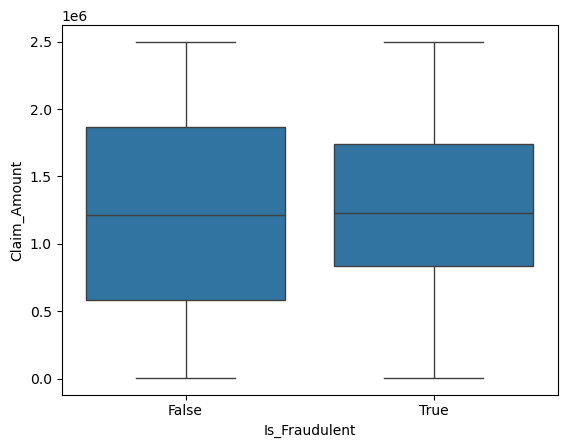

In [17]:
sns.boxplot(x=df["Is_Fraudulent"], y=df["Claim_Amount"])
plt.show()

In [19]:
df['Claim_Date'] = pd.to_datetime(df['Claim_Date'])
df['Service_Date'] = pd.to_datetime(df['Service_Date'])
df['Policy_Expiration_Date'] = pd.to_datetime(df['Policy_Expiration_Date'])


In [21]:
df['Claim_Date'].isna().sum()
df['Service_Date'].isna().sum()
df['Policy_Expiration_Date'].isna().sum()

0

In [23]:
df.head()

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,Rehab/Skilled Nursing,47,Inpatient,3440.06,824.59,0,16,939.08,True,False
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,Deceased,0,Outpatient,3618.40,851.43,0,6,170.40,False,True
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,Deceased,0,Pharmacy,2442.41,616.23,0,2,549.38,True,False
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,Deceased,0,Pharmacy,587.78,459.33,0,2,396.49,False,True
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,Deceased,0,Emergency Room,3047.55,847.40,0,15,865.87,True,False


In [25]:
df['Claim_Service_Delay'] = (df['Claim_Date'] - df['Service_Date']).dt.days
df['Days_To_Expiration_Proximity'] = (df['Policy_Expiration_Date'] - df['Claim_Date']).dt.days
df['Claim_Month'] = df['Claim_Date'].dt.month
df['Claim_DOW'] = df['Claim_Date'].dt.dayofweek

In [27]:
df.head()

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent,Claim_Service_Delay,Days_To_Expiration_Proximity,Claim_Month,Claim_DOW
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,824.59,0,16,939.08,True,False,46,1253,6,2
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,851.43,0,6,170.40,False,True,2,1539,1,6
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,616.23,0,2,549.38,True,False,42,488,5,4
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,459.33,0,2,396.49,False,True,5,1508,11,6
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,847.40,0,15,865.87,True,False,36,1588,3,0


In [29]:
df.shape

(20100, 34)

In [31]:
date_columns_to_drop = ['Claim_Date','Service_Date','Policy_Expiration_Date']
df = df.drop(columns=date_columns_to_drop + ["Patient_ID","Claim_ID","Policy_Number","Hospital_ID"])

In [33]:
df.head()

,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,Patient_State,Provider_Type,Provider_Specialty,Provider_City,Provider_State,Diagnosis_Code,...,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent,Claim_Service_Delay,Days_To_Expiration_Proximity,Claim_Month,Claim_DOW
0,462337.48,28,Female,Houston,WI,Clinic,Cardiology,Los Angeles,WA,A09,...,824.59,0,16,939.08,True,False,46,1253,6,2
1,1883481.30,40,Other,Washington,CO,Laboratory,Cardiology,Dallas,AZ,J02.9,...,851.43,0,6,170.40,False,True,2,1539,1,6
2,1500658.89,90,Female,Seattle,FL,Hospital,Neurology,Phoenix,NC,I25.10,...,616.23,0,2,549.38,True,False,42,488,5,4
3,572237.61,49,Other,Fort Worth,MD,Specialist Office,Pediatrics,Los Angeles,TX,I10,...,459.33,0,2,396.49,False,True,5,1508,11,6
4,2088293.84,24,Female,New York,FL,Specialist Office,Pediatrics,San Diego,PA,H25.9,...,847.40,0,15,865.87,True,False,36,1588,3,0


In [35]:
X = df.drop('Is_Fraudulent', axis = 1)
Y = df['Is_Fraudulent']

In [37]:
print(f'The predictors structure is {X.shape}, the target structure is {Y.shape}')

The predictors structure is (20100, 26), the target structure is (20100,)


In [39]:
categorical = X.select_dtypes(include="object").columns
numerical = X.select_dtypes(exclude="object").columns


In [41]:
categorical

Index(['Patient_Gender', 'Patient_City', 'Patient_State', 'Provider_Type',
       'Provider_Specialty', 'Provider_City', 'Provider_State',
       'Diagnosis_Code', 'Admission_Type', 'Discharge_Type', 'Service_Type'],
      dtype='object')

In [43]:
numerical

Index(['Claim_Amount', 'Patient_Age', 'Procedure_Code', 'Number_of_Procedures',
       'Length_of_Stay_Days', 'Deductible_Amount', 'CoPay_Amount',
       'Number_of_Previous_Claims_Patient',
       'Number_of_Previous_Claims_Provider', 'Provider_Patient_Distance_Miles',
       'Claim_Submitted_Late', 'Claim_Service_Delay',
       'Days_To_Expiration_Proximity', 'Claim_Month', 'Claim_DOW'],
      dtype='object')

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numerical)
    ]
)

In [47]:
model = XGBClassifier(n_estimators=350, max_depth=8, learning_rate=0.05, scale_pos_weight=5)

In [49]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ('smote', SMOTE(sampling_strategy='auto')), 
    ("model", model)
])

In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [53]:
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Patient_Gender', 'Patient_City', 'Patient_State', 'Provider_Type',
       'Provider_Specialty', 'Provider_City', 'Provider_State',
       'Diagnosis_Code', 'Admission_Type', 'Discharge_Type', 'Service_Type'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Claim_Amou...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=350, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [54]:
preds = pipeline.predict(X_test)
probs = pipeline.predict_proba(X_test)[:,1]

In [55]:
print(classification_report(Y_test, preds))
print("AUC:", roc_auc_score(Y_test, probs))

              precision    recall  f1-score   support

       False       0.92      0.86      0.89      3018
        True       0.65      0.78      0.71      1002

    accuracy                           0.84      4020
   macro avg       0.79      0.82      0.80      4020
weighted avg       0.85      0.84      0.85      4020

AUC: 0.8705547817552436


In [71]:
import os
os.makedirs("../ML_models", exist_ok=True)

In [59]:
import joblib 

In [83]:
joblib.dump(pipeline, "../ML_models/smartcare_model.pkl")
print('SmartCare Xgb Model Saved Sucessfully!')

SmartCare Xgb Model Saved Sucessfully!
